# 01 — Data Preprocessing, Feature Engineering & Train/Val/Test Split

This notebook is the **single source of truth** for the data pipeline (Section 3 of the project
spec). Every other notebook (`02_pca_lda`, `03_classification`, `04_regression`, `05_qlearning_dqn`)
and `app.py` builds on the artifacts this notebook saves across the whole
project.

**What this notebook does, in order:**
1. Load the raw transaction data from `Online Retail.xlsx`.
2. Apply the 5 mandatory cleaning steps (Section 3.2), in the exact required order.
3. Build `category_map.json` (Section 3.4) and assign a category to every transaction.
4. Save the cleaned, categorized transaction-level table (`cleaned_transactions.csv`).
5. Engineer the **classification** customer-level features over the full 12-month period
   (Section 3.3): Recency, Frequency, Monetary, Product Diversity, Avg. Spend/Transaction,
   Category Spend % → saved as `customer_features_classification.csv`.
6. Engineer the **regression** customer-level features using only months 1–9 as inputs
   and months 10 to end of dataset total spend as the target (Section 5.3, avoids data leakage)
   → saved as `customer_features_regression.csv`.
7. Perform the **official 80/10/10 train/validation/test split** at the customer level
   (Section 5.1, seed 42) and save `models/customer_split_ids.pkl`.
   This single split is reused unchanged by every downstream notebook.

**What this notebook does NOT do:** it does not create the `High-Value` label or train any model.
Those happen in `02_pca_lda.ipynb` onward. This notebook never writes back to the source
spreadsheet; it only reads it and writes new CSV/JSON/pickle files.

In [17]:
# --- Imports ---
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split

DATA_DIR = Path("../data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Dataset file — renamed to 'Online Retail.xlsx' (sheet: 'Online Retail')
RAW_XLSX = DATA_DIR / "Online Retail.xlsx"
RAW_SHEET_NAME = "Online Retail"

CATEGORY_MAP_PATH = Path("../category_map.json")

RANDOM_STATE = 42

## 1. Load raw data

We load completely unmodified, raw transaction data directly from the Excel sheet. This ensures a fully reproducible pipeline starting from the absolute source of truth. **Column-naming note:** the project spec (Section 3.1)
names the raw columns `InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`,
`UnitPrice`, `CustomerID`, `Country` 

In [ ]:
raw = pd.read_excel(RAW_XLSX, sheet_name=RAW_SHEET_NAME)
print(f"Loaded {len(raw):,} rows from '{RAW_SHEET_NAME}' in {RAW_XLSX.name}")
print("Original columns:", list(raw.columns))

# Normalize column names to the spec's standard naming.
COLUMN_ALIASES = {
    "Invoice": "InvoiceNo",
    "Price": "UnitPrice",
    "Customer ID": "CustomerID",
    "Customer Id": "CustomerID",
}
raw = raw.rename(columns=COLUMN_ALIASES)

REQUIRED_COLUMNS = ["InvoiceNo", "StockCode", "Description", "Quantity",
                     "InvoiceDate", "UnitPrice", "CustomerID", "Country"]
missing = [c for c in REQUIRED_COLUMNS if c not in raw.columns]
assert not missing, f"Missing required columns after renaming: {missing}"

# Keep only the required raw columns from the raw dataset.
raw = raw[REQUIRED_COLUMNS].copy()
print("\nStandardized columns:", list(raw.columns))
raw.head()

Loaded 541,909 rows from 'Online Retail' in Online Retail.xlsx
Original columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Standardized columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Data quality check (before cleaning)

Quick counts of the issues the mandatory cleaning steps are about to fix — useful for the report
("X% of rows dropped because...").

In [ ]:
n_total = len(raw)
n_null_customer = raw["CustomerID"].isna().sum()
n_cancelled = raw["InvoiceNo"].astype(str).str.upper().str.startswith("C").sum()
n_bad_qty_or_price = ((raw["Quantity"] <= 0) | (raw["UnitPrice"] <= 0)).sum()

print(f"Total raw rows:                       {n_total:,}")
print(f"Rows with null CustomerID:             {n_null_customer:,} ({n_null_customer/n_total:.1%})")
print(f"Rows with cancelled InvoiceNo ('C..'):  {n_cancelled:,} ({n_cancelled/n_total:.1%})")
print(f"Rows with Quantity <= 0 or UnitPrice <= 0:  {n_bad_qty_or_price:,} ({n_bad_qty_or_price/n_total:.1%})")

Total raw rows:                       541,909
Rows with null CustomerID:             135,080 (24.9%)
Rows with cancelled InvoiceNo ('C..'):  9,288 (1.7%)
Rows with Quantity<=0 or UnitPrice<=0:  11,805 (2.2%)


## 3. Mandatory cleaning steps (Section 3.2 — performed in this exact order)

1. Drop rows where `CustomerID` is null.
2. Remove cancelled orders (`InvoiceNo` starting with `"C"`).
3. Remove rows where `Quantity <= 0` or `UnitPrice <= 0`.
4. Create `TotalPrice = Quantity * UnitPrice`.
5. Set the snapshot date to one day after the last invoice date (used for Recency).

Row counts are printed after each step so the cumulative effect of cleaning is traceable.

In [ ]:
df = raw.copy()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(f"Start:                              {len(df):,} rows")

# Step 1 — drop rows with null CustomerID
df = df.dropna(subset=["CustomerID"]).copy()
print(f"After dropping null CustomerID:      {len(df):,} rows")

# Step 2 — remove cancelled orders (InvoiceNo starting with 'C')
df = df[~df["InvoiceNo"].astype(str).str.upper().str.startswith("C")].copy()
print(f"After removing cancelled orders:     {len(df):,} rows")

# Step 3 — remove non-positive Quantity or UnitPrice
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()
print(f"After removing Qty<=0 / Price<=0:    {len(df):,} rows")

# Step 4 — TotalPrice
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# CustomerID as a clean integer ID
df["CustomerID"] = df["CustomerID"].astype(int)

# Step 5 — snapshot date = one day after the last invoice date in the (cleaned) dataset
SNAPSHOT_DATE = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"\nSnapshot date: {SNAPSHOT_DATE}")
print(f"Final cleaned row count: {len(df):,}")
print(f"Unique customers remaining: {df['CustomerID'].nunique():,}")

#if cleaning drops customers below ~2,000, re-check the filters above.
n_customers = df["CustomerID"].nunique()
if n_customers < 2000:
    print(f"WARNING: only {n_customers} customers remain after cleaning — re-check the "
          f"cancelled-order and null-CustomerID filters.")
else:
    print("Customer count looks healthy (>= 2,000).")

Start:                              541,909 rows
After dropping null CustomerID:      406,829 rows
After removing cancelled orders:     397,924 rows
After removing Qty<=0 / Price<=0:    397,884 rows

Snapshot date: 2011-12-10 12:50:00
Final cleaned row count: 397,884
Unique customers remaining: 4,338
Customer count looks healthy (>= 2,000).


## 4. Product category mapping (Section 3.4)

Every transaction is assigned to exactly one of 5 fixed categories using case-insensitive keyword
matching on `Description`, applied in a fixed priority order; anything that matches none of the
keyword lists falls back to `"Other"`. The keyword lists live in `category_map.json` at the
project root (already created) — this notebook only **reads** that file so the mapping stays
reproducible and shared by every notebook / by `app.py`. Note that `category_map.json` doesn't
need an `"Other"` entry: `Other` is just the fallback used when none of the 5 keyword lists
match, not a category with keywords of its own.

In [ ]:
# Load the existing keyword map.
with open(CATEGORY_MAP_PATH) as f:
    category_map = json.load(f)
print(f"Loaded category keyword map from {CATEGORY_MAP_PATH}:")
print(json.dumps(category_map, indent=2))

# Priority order in which categories are checked (Section 3.4). This order isn't stored in the
# JSON file itself (JSON key order isn't a reliable place to encode logic), so it's fixed here.
# "Other" has no keywords of its own - it's just the fallback when nothing else matches.
CATEGORY_PRIORITY = ["Homeware", "Stationery", "Gadgets", "Decorations", "Kitchenware", "Other"]


def assign_category(description: str) -> str:
    # Return the first category (in priority order) whose keyword appears in the description.
    if pd.isna(description):
        return "Other"
    desc_upper = str(description).upper()
    for cat in CATEGORY_PRIORITY:
        if cat == "Other":
            continue
        if any(kw in desc_upper for kw in category_map.get(cat, [])):
            return cat
    return "Other"


df["Category"] = df["Description"].apply(assign_category)

print("\nTransactions per category:")
print(df["Category"].value_counts())

Loaded category keyword map from ..\category_map.json:
{
  "Homeware": [
    "HOME",
    "MUG",
    "CANDLE",
    "LANTERN",
    "CUSHION"
  ],
  "Stationery": [
    "CARD",
    "NOTEBOOK",
    "PEN",
    "PAPER",
    "ENVELOPE"
  ],
  "Gadgets": [
    "LIGHT",
    "CLOCK",
    "BATTERY",
    "ALARM"
  ],
  "Decorations": [
    "CHRISTMAS",
    "DECORATION",
    "BUNTING",
    "GARLAND"
  ],
  "Kitchenware": [
    "BAKING",
    "CAKE",
    "TIN",
    "JAR",
    "BOWL"
  ]
}

Transactions per category:
Category
Other          245632
Kitchenware     41393
Stationery      33483
Decorations     30431
Gadgets         23573
Homeware        23372
Name: count, dtype: int64


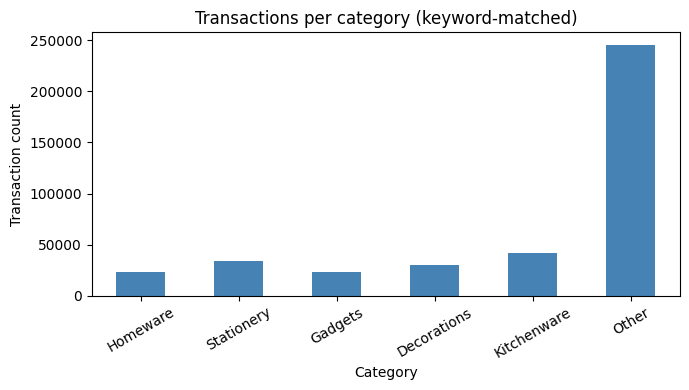

In [24]:
# Sanity-check plot: how the category keyword matching split up the transactions.
plt.figure(figsize=(7, 4))
df["Category"].value_counts().reindex(CATEGORY_PRIORITY).plot(kind="bar", color="steelblue")
plt.ylabel("Transaction count")
plt.title("Transactions per category (keyword-matched)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(DATA_DIR / "category_counts.png", dpi=150)
plt.show()

## 5. Save the cleaned, categorized transaction-level table

This row-level file is needed later — most importantly by `04_regression.ipynb`, which requires
month-level aggregation (train features from months 1–9, target = spend in months 10 to end of
dataset) and so needs `InvoiceDate` at the transaction level, not just the final customer summary.

In [25]:
cleaned_path = DATA_DIR / "cleaned_transactions.csv"
df.to_csv(cleaned_path, index=False)
print(f"Saved cleaned transaction-level data to {cleaned_path}  ({len(df):,} rows)")

# Persist the snapshot date too, since Recency (and potentially other notebooks) depend on it.
with open(DATA_DIR / "snapshot_date.json", "w") as f:
    json.dump({"snapshot_date": SNAPSHOT_DATE.isoformat()}, f, indent=2)
print(f"Saved snapshot date ({SNAPSHOT_DATE.date()}) to data/snapshot_date.json")

Saved cleaned transaction-level data to ..\data\cleaned_transactions.csv  (397,884 rows)
Saved snapshot date (2011-12-10) to data/snapshot_date.json


## 6. Customer-level feature engineering for Classification (Section 3.3)

Aggregated over the **full 12-month period** — used by `02_pca_lda.ipynb` and
`03_classification.ipynb`.

| Feature | Definition |
|---|---|
| Recency (R) | (Snapshot date − date of customer's last invoice), in days |
| Frequency (F) | Count of distinct `InvoiceNo` values for the customer |
| Monetary (M) | Sum of `TotalPrice` across all the customer's transactions |
| Product Diversity | Count of distinct `StockCode` values purchased |
| Avg. Spend / Transaction | Monetary ÷ Frequency |
| Category Spend % | (spend in category ÷ Monetary) × 100, for each of the 5 fixed categories |

In [ ]:
customer_agg = df.groupby("CustomerID").agg(
    Max_InvoiceDate=("InvoiceDate", "max"),
    Monetary=("TotalPrice", "sum"),
    Frequency=("InvoiceNo", "nunique"),
    Product_Diversity=("StockCode", "nunique"),
).reset_index()

customer_agg["Recency"] = (SNAPSHOT_DATE - customer_agg["Max_InvoiceDate"]).dt.days
customer_agg["Avg_Spend_Trans"] = customer_agg["Monetary"] / customer_agg["Frequency"]

# Category Spend % — spend in each category as a % of the customer's total Monetary value.
# Note: the spec lists 5 fixed categories in Section 3.4's mapping table, but keyword matching
# also produces an "Other" bucket for anything unmatched — so the pivot below has 6 columns.
# All 6 are computed and saved here.
category_spend = df.groupby(["CustomerID", "Category"])["TotalPrice"].sum().unstack(fill_value=0)
category_pct = category_spend.div(category_spend.sum(axis=1), axis=0) * 100
category_pct = category_pct.reindex(columns=CATEGORY_PRIORITY, fill_value=0.0)  # consistent column order
category_pct = category_pct.reset_index()

customer_df = customer_agg.merge(category_pct, on="CustomerID", how="left")
customer_df = customer_df.drop(columns=["Max_InvoiceDate"])

print(f"customer_df (classification) shape: {customer_df.shape}")
customer_df.head()

customer_df (classification) shape: (4338, 12)


,CustomerID,Monetary,Frequency,Product_Diversity,Recency,Avg_Spend_Trans,Homeware,Stationery,Gadgets,Decorations,Kitchenware,Other
0,12346,77183.60,1,1,326,77183.600000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000
1,12347,4310.00,7,103,2,615.714286,1.728074,11.770302,20.121578,0.236659,11.445476,54.697912
2,12348,1797.24,4,22,75,449.310000,0.000000,23.035321,0.000000,3.538759,15.023035,58.402884
3,12349,1757.55,1,73,19,1757.550000,8.145430,0.443800,2.691246,1.433814,18.125231,69.160479
4,12350,334.40,1,17,310,334.400000,0.000000,0.000000,0.000000,0.000000,11.842105,88.157895


## 7. Sanity checks (classification features)

Quick checks before saving: no missing values, percentages sum to 100, and value ranges look
reasonable (useful to catch bugs now rather than three notebooks downstream).

In [27]:
assert customer_df.isna().sum().sum() == 0, "Unexpected missing values in customer_df"

pct_cols = CATEGORY_PRIORITY
pct_sums = customer_df[pct_cols].sum(axis=1)
assert np.allclose(pct_sums, 100.0, atol=1e-6), "Category percentages do not sum to 100 for some customers"

assert (customer_df["Recency"] >= 0).all(), "Found negative Recency — check snapshot date logic"
assert (customer_df["Frequency"] >= 1).all(), "Found a customer with zero invoices"
assert (customer_df["Monetary"] > 0).all(), "Found a customer with non-positive Monetary"

print("All sanity checks passed.")
customer_df.describe()

All sanity checks passed.


,CustomerID,Monetary,Frequency,Product_Diversity,Recency,Avg_Spend_Trans,Homeware,Stationery,Gadgets,Decorations,Kitchenware,Other
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,2054.266460,4.272015,61.501153,92.536422,419.166289,6.522583,6.612488,7.938209,7.860871,10.530471,60.535378
std,1721.808492,8989.230441,7.697998,85.366768,100.014169,1796.537944,9.302089,9.340562,12.684207,11.475319,12.856430,20.584452
min,12346.000000,3.750000,1.000000,1.000000,1.000000,3.450000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13813.250000,307.415000,1.000000,16.000000,18.000000,178.625000,0.000000,0.000000,0.000000,0.000000,1.510402,49.487511
50%,15299.500000,674.485000,2.000000,35.000000,51.000000,293.900000,3.917796,4.031862,3.990977,4.394675,7.332722,61.731186
75%,16778.750000,1661.740000,5.000000,77.000000,142.000000,430.113750,8.912067,9.029858,10.339343,10.835541,14.374307,73.294844
max,18287.000000,280206.020000,209.000000,1787.000000,374.000000,84236.250000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


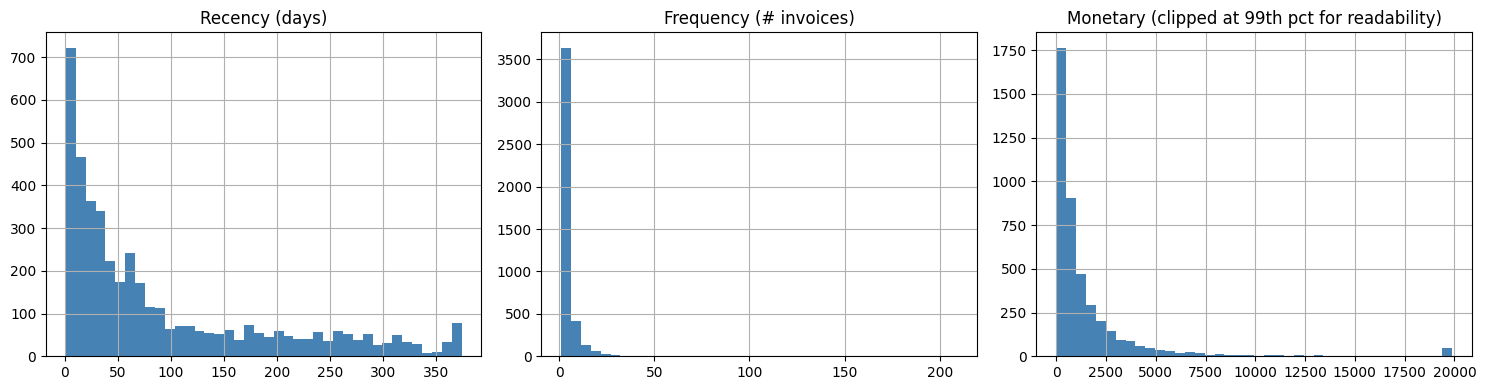

In [28]:
# Quick distribution plots for the report.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
customer_df["Recency"].hist(bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Recency (days)")
customer_df["Frequency"].hist(bins=40, ax=axes[1], color="steelblue")
axes[1].set_title("Frequency (# invoices)")
customer_df["Monetary"].clip(upper=customer_df["Monetary"].quantile(0.99)).hist(bins=40, ax=axes[2], color="steelblue")
axes[2].set_title("Monetary (clipped at 99th pct for readability)")
plt.tight_layout()
plt.savefig(DATA_DIR / "customer_feature_distributions.png", dpi=150)
plt.show()

## 8. Save the classification customer-level feature table

In [29]:
clf_features_path = DATA_DIR / "customer_features_classification.csv"
customer_df.to_csv(clf_features_path, index=False)
print(f"Saved classification feature table to {clf_features_path}  ({len(customer_df):,} customers)")

Saved classification feature table to ..\data\customer_features_classification.csv  (4,338 customers)


## 9. Customer-level feature engineering for Regression (Section 5.3)

To avoid **data leakage**, the regression task requires:
- **Input features** computed only from transactions in **months 1–9** of the dataset date range.
- **Target** (`Target_Monetary`) = total spend in **months 10 to end of dataset** (all remaining
  transactions after the feature window, including early-December holiday sales).

"Month 1" is defined as the calendar month of the earliest transaction after cleaning.
We restrict to customers who have at least one transaction in months 1–9 (they form the feature
rows); the target is 0 for customers with no purchases after the feature period.

> **Why no hard ceiling on the target period?** The Online Retail dataset runs until December 9,
> 2011. Capping the target at December 1st (exactly 12 calendar months from month_1_start) would
> silently discard 9 days of high-volume holiday sales from the target labels. We instead capture
> every transaction from `feature_cutoff` onwards so no data is wasted.

> **Why separate from the classification table?** The classification features use the full year,
> so they already encode post-feature-period behavior. Loading that table for regression would
> leak the future into the predictors and artificially inflate model performance.

In [ ]:
# Determine the date range of the cleaned dataset.
date_min = df["InvoiceDate"].min()
date_max = df["InvoiceDate"].max()
print(f"Cleaned data date range: {date_min.date()}  →  {date_max.date()}")

# Define month boundaries using the first day of month_1 as the anchor.
# month_1_start = first day of the month containing the earliest transaction.
month_1_start = date_min.replace(day=1)

# Cutoff between months 9 and 10 (exclusive upper bound for the feature period).
# pd.DateOffset(months=9) moves forward exactly 9 calendar months.
feature_cutoff = month_1_start + pd.DateOffset(months=9)

print(f"Month 1 starts:  {month_1_start.date()}")
print(f"Feature period:  months 1–9   →  [{month_1_start.date()}, {feature_cutoff.date()})")
print(f"Target period:   months 10–12+ →  [{feature_cutoff.date()}, {date_max.date()}]")

# Split the cleaned transactions into the two periods.
# No upper cap on df_target — we capture all transactions from feature_cutoff to the
# last day of the dataset (Dec 9, 2011) so that nodata is discarded.
df_feat   = df[df["InvoiceDate"] <  feature_cutoff].copy()   # months 1–9
df_target = df[df["InvoiceDate"] >= feature_cutoff].copy()   # months 10 to end of dataset

print(f"\nTransactions in feature period (months 1–9):          {len(df_feat):,}")
print(f"Transactions in target period  (month 10 → dataset end): {len(df_target):,}")

Cleaned data date range: 2010-12-01  →  2011-12-09
Month 1 starts:  2010-12-01
Feature period:  months 1–9   →  [2010-12-01, 2011-09-01)
Target period:   months 10–12+ →  [2011-09-01, 2011-12-09]

Transactions in feature period (months 1–9):          226,469
Transactions in target period  (month 10 → dataset end): 171,415


In [31]:
# --- Snapshot date for Recency in the regression task ---
# To prevent feature distortion, the snapshot date must be set relative to the end
# of the Month 9 feature window — NOT the global December snapshot.
# Using the global snapshot would make every customer appear as a long-lapsed customer
# (e.g., someone active on Aug 31 shows Recency > 100 days instead of ~1 day),
# completely destroying the predictive signal of Recency for the regression model.
REG_SNAPSHOT_DATE = df_feat["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Regression snapshot date (end of Month 9 window): {REG_SNAPSHOT_DATE.date()}")

# --- Aggregate features from months 1–9 ---
reg_agg = df_feat.groupby("CustomerID").agg(
    Max_InvoiceDate=("InvoiceDate", "max"),
    Monetary=("TotalPrice", "sum"),
    Frequency=("InvoiceNo", "nunique"),
    Product_Diversity=("StockCode", "nunique"),
).reset_index()

reg_agg["Recency"]        = (REG_SNAPSHOT_DATE - reg_agg["Max_InvoiceDate"]).dt.days
reg_agg["Avg_Spend_Trans"] = reg_agg["Monetary"] / reg_agg["Frequency"]

# Category Spend % — computed only over the feature period (months 1–9).
reg_cat_spend = df_feat.groupby(["CustomerID", "Category"])["TotalPrice"].sum().unstack(fill_value=0)
reg_cat_pct   = reg_cat_spend.div(reg_cat_spend.sum(axis=1), axis=0) * 100
reg_cat_pct   = reg_cat_pct.reindex(columns=CATEGORY_PRIORITY, fill_value=0.0)
reg_cat_pct   = reg_cat_pct.reset_index()

reg_df = reg_agg.merge(reg_cat_pct, on="CustomerID", how="left")
reg_df = reg_df.drop(columns=["Max_InvoiceDate"])

# --- Build the regression target: total spend from month 10 to end of dataset ---
target_spend = df_target.groupby("CustomerID")["TotalPrice"].sum().rename("Target_Monetary").reset_index()

# Merge: customers with no purchases after the feature period get Target_Monetary = 0.
reg_df = reg_df.merge(target_spend, on="CustomerID", how="left")
reg_df["Target_Monetary"] = reg_df["Target_Monetary"].fillna(0.0)

print(f"Regression feature table shape: {reg_df.shape}")
print(f"  Customers with Target_Monetary > 0: {(reg_df['Target_Monetary'] > 0).sum()}")
print(f"  Customers with Target_Monetary = 0: {(reg_df['Target_Monetary'] == 0).sum()}")
reg_df.head()

Regression snapshot date (end of Month 9 window): 2011-09-02
Regression feature table shape: (3317, 13)
  Customers with Target_Monetary > 0: 1952
  Customers with Target_Monetary = 0: 1365


,CustomerID,Monetary,Frequency,Product_Diversity,Recency,Avg_Spend_Trans,Homeware,Stationery,Gadgets,Decorations,Kitchenware,Other,Target_Monetary
0,12346,77183.60,1,1,226,77183.600000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.00
1,12347,2790.86,5,82,30,558.172000,1.461915,11.770565,17.340891,0.000000,11.860143,57.566485,1519.14
2,12348,1487.24,3,22,149,495.746667,0.000000,19.768161,0.000000,4.276378,18.154434,57.801027,310.00
3,12350,334.40,1,17,211,334.400000,0.000000,0.000000,0.000000,0.000000,11.842105,88.157895,0.00
4,12352,1561.81,5,26,163,312.362000,5.334196,0.000000,2.176961,1.133300,10.257330,81.098213,944.23


In [32]:
# Sanity checks for regression features.
assert reg_df.isna().sum().sum() == 0, "Unexpected NaN values in regression feature table"
assert (reg_df["Recency"] >= 0).all(), "Found negative Recency in regression table"
assert (reg_df["Frequency"] >= 1).all(), "Found customer with zero invoices in feature period"
assert (reg_df["Monetary"] > 0).all(), "Found non-positive Monetary in feature period"
assert (reg_df["Target_Monetary"] >= 0).all(), "Found negative Target_Monetary"

print("All regression sanity checks passed.")
reg_df.describe()

All regression sanity checks passed.


,CustomerID,Monetary,Frequency,Product_Diversity,Recency,Avg_Spend_Trans,Homeware,Stationery,Gadgets,Decorations,Kitchenware,Other,Target_Monetary
count,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000,3317.000000
mean,15284.195659,1579.523835,3.441061,49.088031,93.137172,400.570243,6.363906,6.350172,7.729000,5.697611,11.545925,62.313386,914.237200
std,1724.184899,5976.598196,5.586520,66.187556,76.702672,1435.759981,9.638082,9.960712,13.192869,10.755668,13.753635,21.317325,5187.733282
min,12346.000000,2.900000,1.000000,1.000000,1.000000,2.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13799.000000,261.360000,1.000000,13.000000,28.000000,169.370000,0.000000,0.000000,0.000000,0.000000,1.451858,51.231527,0.000000
50%,15245.000000,555.650000,2.000000,29.000000,73.000000,284.550000,3.471740,3.361987,3.224034,1.625964,8.294817,63.706366,202.020000
75%,16770.000000,1355.110000,4.000000,62.000000,147.000000,415.213333,8.832445,8.471344,9.936844,7.420173,16.156546,75.896428,748.170000
max,18287.000000,176355.940000,127.000000,1190.000000,274.000000,77183.600000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,168469.600000


## 10. Save the regression customer-level feature table

In [33]:
reg_features_path = DATA_DIR / "customer_features_regression.csv"
reg_df.to_csv(reg_features_path, index=False)
print(f"Saved regression feature table to {reg_features_path}  ({len(reg_df):,} customers)")

Saved regression feature table to ..\data\customer_features_regression.csv  (3,317 customers)


## 11. Official 80/10/10 Train / Validation / Test Split (Section 5.1)

The split is performed **at the customer level** using `random_state=42`, producing:
- **80%** → training set
- **10%** → validation set
- **10%** → test set

**Critical design decision:** The split is computed once, here, on the full customer population
from `customer_features_classification.csv`. The same `CustomerID` lists are reused unchanged by
`02_pca_lda.ipynb`, `03_classification.ipynb`, `04_regression.ipynb`, and `05_qlearning_dqn.ipynb`.

Saved to `models/customer_split_ids.pkl` as a dict with keys
`{"train_ids", "val_ids", "test_ids"}`.

In [ ]:
all_customer_ids = customer_df["CustomerID"]

# Step 1: Carve off the 10% test set.
train_val_ids, test_ids = train_test_split(
    all_customer_ids, test_size=0.10, random_state=RANDOM_STATE
)

# Step 2: Split the remaining 90% into train (80% of total) and val (10% of total).
# 10% of total / 90% of total = 1/9 ≈ 0.1111 of the remainder.
train_ids, val_ids = train_test_split(
    train_val_ids, test_size=(0.10 / 0.90), random_state=RANDOM_STATE
)

n_total = len(all_customer_ids)
print(f"Total customers:  {n_total}")
print(f"Train:            {len(train_ids)} ({len(train_ids)/n_total:.1%})")
print(f"Validation:       {len(val_ids)}  ({len(val_ids)/n_total:.1%})")
print(f"Test:             {len(test_ids)}  ({len(test_ids)/n_total:.1%})")

# Verify the percentages are correct.
assert abs(len(train_ids)/n_total - 0.80) < 0.02, "Train split not ~80%"
assert abs(len(val_ids)/n_total   - 0.10) < 0.02, "Validation split not ~10%"
assert abs(len(test_ids)/n_total  - 0.10) < 0.02, "Test split not ~10%"

split_payload = {
    # Stored as typed Python int lists rather than raw NumPy arrays.
    # This avoids serialization edge-cases when the PKL is consumed by
    # downstream notebooks, app.py.
    "train_ids": train_ids.astype(int).tolist(),
    "val_ids":   val_ids.astype(int).tolist(),
    "test_ids":  test_ids.astype(int).tolist(),
}
joblib.dump(split_payload, MODELS_DIR / "customer_split_ids.pkl")
print(f"\nSaved official 80/10/10 split to models/customer_split_ids.pkl")

Total customers:  4338
Train:            3470 (80.0%)
Validation:       434  (10.0%)
Test:             434  (10.0%)

Saved official 80/10/10 split to models/customer_split_ids.pkl


## 12. Artifacts saved by this notebook

| File | Description |
|---|---|
| `data/cleaned_transactions.csv` | Cleaned + categorized transaction-level data (needed by `04_regression.ipynb`) |
| `data/snapshot_date.json` | Snapshot date used for Recency computation (classification) |
| `data/customer_features_classification.csv` | Full-year customer RFM + category-spend-% features (used by `02_pca_lda` and `03_classification`) |
| `data/customer_features_regression.csv` | Months 1–9 features + `Target_Monetary` (months 10 to end of dataset) — no leakage |
| `models/customer_split_ids.pkl` | Official 80/10/10 customer-level split, reused by every downstream notebook |
| `data/category_counts.png` | Bar chart of transactions per category |
| `data/customer_feature_distributions.png` | R/F/M distribution histograms |

None of these steps write back to the original `Online Retail.xlsx` file — it is only read.

**Next notebook:** `02_pca_lda.ipynb` loads `customer_features_classification.csv` and the
official split from `customer_split_ids.pkl`, then runs PCA and LDA (Sections 4.2–4.4).